import

In [9]:
%matplotlib inline
import pandas as pd
from cd_library import draw_cd_diagram
from matplotlib import pyplot as plt

caricamnto csv

In [2]:
df = pd.read_csv('csvDatiManuale.csv')

manipolazione colonne e pulizia dati

In [3]:
# Crea la colonna total_time_seconds
df['total_time_seconds'] = df['fit_time'] + df['predict_time']
# Rinomina le colonne per la libreria hfawaz
# La libreria si aspetta: 'classifier_name', 'dataset_name', 'accuracy'
df_perf = df.rename(columns={
    'algorithm': 'classifier_name',
    'dataset': 'dataset_name',
    'accuracy': 'accuracy'
})
# Gestione dati mancanti
# righe senza accuracy (NaN) fanno fallire la statistica. Le rimuoviamo per il grafico
df_perf = df_perf.dropna(subset=['accuracy'])

# Se hai varianti dello stesso algoritmo, rendile uniche
#df_perf['classifier_name'] = df_perf['classifier_name'] + "_" + df_perf['variant']

critical difference diagram per accuracy

['Rocket' 'Arsenal' 'Boss']
Arsenal    3.0
Boss       2.0
Rocket     3.0
dtype: float64
Boss       2.583333
Rocket     1.791667
Arsenal    1.625000
dtype: float64
('Arsenal', 'Boss', np.float64(0.0078125), True)
('Boss', 'Rocket', np.float64(0.0107421875), True)
('Arsenal', 'Rocket', np.float64(0.7890625), False)
Index(['Boss', 'Rocket', 'Arsenal'], dtype='object')
[1, 2]


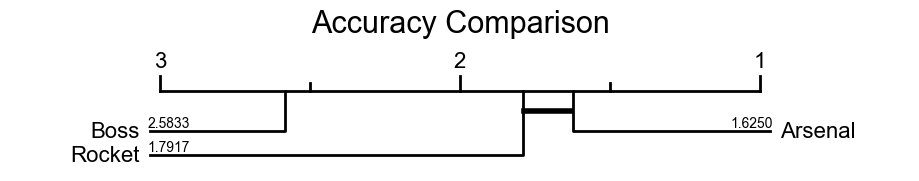

In [11]:
draw_cd_diagram(df_perf=df_perf, title='Accuracy Comparison', labels=True)

barplot per i tempi

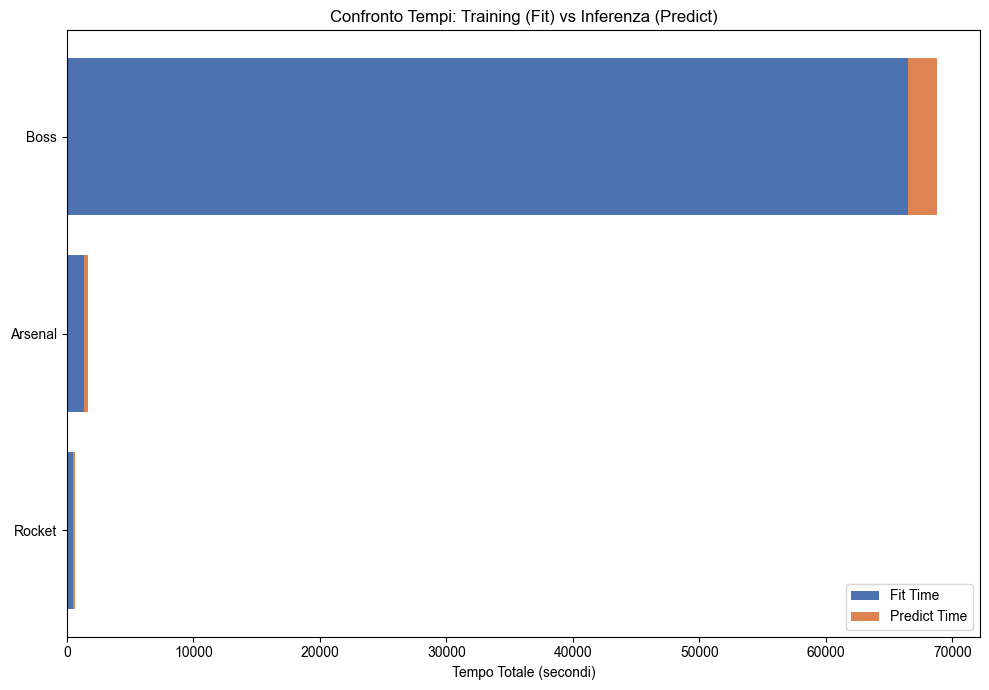

In [15]:
# 1. Aggreghiamo i tempi per algoritmo (facciamo la media su tutti i dataset o la somma)
# Usiamo la somma per vedere il carico totale di lavoro
df_agg = df_perf.groupby('classifier_name')[['fit_time', 'predict_time']].sum().reset_index()

# 2. Ordiniamo per tempo totale per rendere il grafico leggibile
df_agg['total'] = df_agg['fit_time'] + df_agg['predict_time']
df_agg = df_agg.sort_values('total', ascending=True)

# 3. Creazione del plot
fig, ax = plt.subplots(figsize=(10, 7))

# Disegniamo la parte del Fit Time
ax.barh(df_agg['classifier_name'], df_agg['fit_time'], label='Fit Time', color='#4c72b0')

# Disegniamo la parte del Predict Time "sopra" (o meglio, a destra) del Fit Time
ax.barh(df_agg['classifier_name'], df_agg['predict_time'], left=df_agg['fit_time'],
        label='Predict Time', color='#dd8452')

# 4. Abbellimento
ax.set_xlabel('Tempo Totale (secondi)')
ax.set_title('Confronto Tempi: Training (Fit) vs Inferenza (Predict)')
ax.legend()

# Se i tempi variano enormemente tra gli algoritmi, decommenta la riga sotto:
# ax.set_xscale('log')

plt.tight_layout()
plt.savefig('confronto_tempi_stacked.png', bbox_inches='tight')
plt.show()

  classifier_name  fit_time  predict_time
2          Rocket    507.56        134.89
0         Arsenal   1377.70        298.52
1            Boss  66459.55       2278.41
